<!-- Author: Mai Tanaka
Date: 2026-03-31

Feel free to copy and use this Jupyter notebook in full or in parts for your own data science projects.
-->

# Introduction

The Japan Meteorological Agency ([JMA](https://www.jma.go.jp/jma/index.html)) monitors and records rainfall, wind speed and direction, temperature and relative humidity from over 840 sites across Japan through their Automated Meteorological Data Acquisition System (AMEDAS) [@JMA_amedas2026]. Much of this data are publicly available online, and some datasets can be downloaded as CSV files. However, learning to scrape weather data directly from their website is useful because:
- Not all JMA datasets are available as CSV downloads
- Downloading hundreds of days of data from multiple weather stations manually can be painful

Data scraping allows you to retrieve any weather data available on the JMA website, automatically. This means that once the code is set up, you can collect weather data in a consistent and reproducible manner. The code can be easily modied to scrape data from different dates or weather stations.

In this tutorial, I'll walk through a method to scrape and parse 10-minute interval weather data of the Tokyo JMA weather station using Python libraries `requests` and `Beautiful Soup`.

## What You'll Learn in This Tutorial
By the end of this tutorial, you'll learn how to:
- **Scrape tabular weather data** from JMA's website using `requests` library
- **Parse and give structure** to the raw data with `Beautiful Soup` library
- **Clean and save** the data as a CSV file

If you prefer to skip the explanations and jump straight to the implementation, you can download [this blog post](https://github.com/MaiAndResearch/DataDrivenMai_Blogs/blob/main/Japan_Meteorological_Agency/JMA_Data_Scraping_Parsing_.ipynb) as a Jupyter notebook. 

Just make sure to that the appropriate directory for saving the CSV file exists.



## Prerequisites
- A copy of [this blog as a Jupyter notebook](https://github.com/MaiAndResearch/DataDrivenMai_Blogs/blob/main/Japan_Meteorological_Agency/JMA_Data_Scraping_Parsing_.ipynb)
- 'SampleData_JMA' subfolder for saving the CSV output

## Jargon

**Data scraping**: Using code to extract information from a web page or other source that's primarily designed for human viewing. In this blog, we'll be pulling data from an HTML table on the JMA site.

**Data parsing**: Converting raw or unstructured text into something structured and easy to work with. For example, turning HTML table rows into a tidy `pandas` DataFrame.


# Scrape, Parse and Save Japan Weather Data

The outline for collecting weather data from the JMA website is as follows:
1. Find the URL you want to retrieve data from
2. Use `requests` library to scrape data
3. Use an HTML parser and `Beautiful Soup` library to give structure to the raw data
4. Navigate the HTML to extract just the desired data
5. Convert the desired data into a `pandas` Dataframe
6. Save the DataFrame as a CSV file

Let's start with step 1.

## Step 1: Designate the URL with the Weather Data

First, we'll need the URL of the JMA webpage that contains the data we want to scrape. If you'd like to know the actual data scraping and parsing methods, and do not care much for finding a specific JMA station, skip ahead to [step 2](#step-2). 

You can navigate the records of past weather data from [here](https://www.data.jma.go.jp/stats/etrn/index.php). Refer to @fig-findURL below to:

1. Narrow down on the JMA weather site by designating the prefecture (red box)
2. Pinpoint the observation site within the prefecture (orange box, activated once you designate the prefecture)
3. Choose the year, month and day for the desired data (green box)
4. Select the type of weather data to access (blue box)


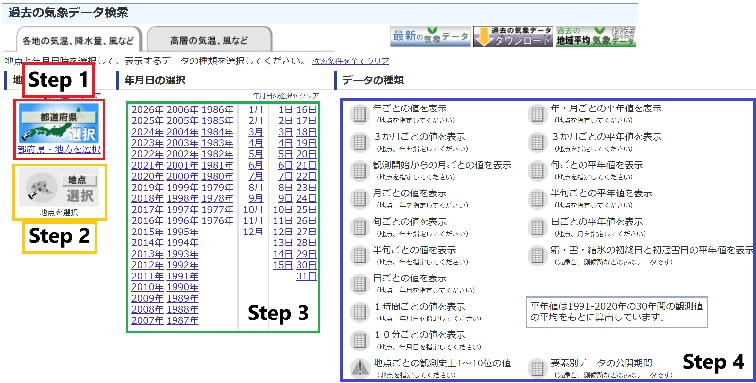{#fig-findURL}

You may need a combination of Google maps, a translation app and trial and error to navigate to your desired URL. You'll also notice that the column headers in the tables differ depending on the type of data you've selected from the blue box in @fig-findURL.

For the remainder of this blog post, we'll work with the 10-minute interval weather records. You can select the "１０分ごとの値" option located on the left column within the blue box, second from the bottom for a JMA observation site and date of your preference. I've provided a default test URL, which accesses 10-minute interval weather records from the Tokyo site on March 9, 2024. 

In [1]:
# URL containing 10-minute interval weather data from Tokyo site on March 9, 2024
# Can be replaced with 10-minute data from any 's1' type observation site
testURL = 'https://www.data.jma.go.jp/stats/etrn/view/10min_s1.php?prec_no=44&block_no=47662&year=2024&month=3&day=9&view='

Accessing this URL, we find the tabular weather data which we will be scraping:

Weather data recorded every 10 minutes from the JMA Tokyo observation site on March 9, 2024{#fig-10min}

## Step 2: Data Scraping with the `requests` library {#step-2}
Import the `requests` library.

In [2]:
# Library required for data scraping
import requests

The `requests.get()` function inside this library sends an HTTP GET request to the designated URL:

In [3]:
# HTTP GET request to testURL
# Execute care to avoid running multiple requests in a very short period of time
step2_resp = requests.get(testURL)

This returns a `Response` object, a class defined by the `requests` library that stores the server's reply when accessing the designated URL.

In [4]:
print("Returned object type:\n\t", type(step2_resp))

# Properties of Response object
step2_prop = step2_resp.__dict__.keys()
print("\nProperties and attributes in object:")
for prop_now in step2_prop:
    print('\t', prop_now)

Returned object type:
	 <class 'requests.models.Response'>

Properties and attributes in object:
	 _content
	 _content_consumed
	 _next
	 status_code
	 headers
	 raw
	 url
	 encoding
	 history
	 reason
	 cookies
	 elapsed
	 request
	 connection


The `Response` object comes with several useful attributes, which are handy for basic error handling. Refer to my [short blog post](https://datadrivenmai.com/blog/) for details.

For now, we'll parse the HTML content using `Beautiful Soup`.

## Step 3: Initial HTML Parsing with `Beautiful Soup`

With the response in hand, we can now parse the raw HTML. Import the `BeautifulSoup()` function from `bs4`:

In [5]:
from bs4 import BeautifulSoup

Parse the contents of the `Response` object from step 2 with Python's built-in html parser, `html.parser`. This will return a `BeautifulSoup` object.

In [6]:
# HTML parse the Response object
step3_soup = BeautifulSoup(step2_resp.content, "html.parser")
print("Returned object type:\n\t", type(step3_soup))

Returned object type:
	 <class 'bs4.BeautifulSoup'>


By parsing HTML with `Beautiful Soup`, we can navigate the contents of the HTML. Namely, HTML consists of tags that define specific sections within the content. Most elements follow the pattern:

```
<tag_name> ...content... </tag_name>
```

These tags are nested in a form of hierarchy. For example, every webpage can be broadly divided into two major sections:

- `<head>` - metadata, scripts, page title
- `<body>` - the visible content, including the tabular data

Let us print just the `<head>` section to see a concise example of structured HTML:


In [7]:
print(step3_soup.head.prettify())

<head>
 <meta charset="utf-8"/>
 <title>
  気象庁｜過去の気象データ検索
 </title>
 <meta content="気象庁 Japan Meteorological Agency" name="Author"/>
 <meta content="気象庁 Japan Meteorological Agency" name="keywords"/>
 <meta content="気象庁｜過去の気象データ検索" name="description"/>
 <meta content="text/css" http-equiv="Content-Style-Type"/>
 <meta content="text/javascript" http-equiv="Content-Script-Type"/>
 <link href="/com/css/define.css" media="all" rel="stylesheet" type="text/css"/>
 <link href="../../css/default.css" media="all" rel="stylesheet" type="text/css"/>
 <script language="JavaScript" src="/com/js/jquery.js" type="text/JavaScript">
 </script>
 <script language="JavaScript" src="../js/jquery.tablefix.js" type="text/JavaScript">
 </script>
 <style media="all" type="text/css">
  <!-- @import url(/com/default.css); -->
 </style>
 <link href="../../data/css/kako.css" media="all" rel="stylesheet" type="text/css"/>
 <link href="../../data/css/print.css" media="print" rel="stylesheet" type="text/css"/>
</head

We can see the nested hierarchy structure in lines 3 to 5 above with:

```
<title>
気象庁｜過去の気象データ検索
</title>
```

In a similar manner, the tabular data to extract is contained within `<body> ...tabular data... </body>`.

## Step 4: Navigate the HTML and Extract the Desired Table

Unfortunately, the HTML body contains much more than the tabular data. If you are curious as to just how much content is inside the HTML body, try running the following code on your own:

```
print(step3_soup.body)
```

You can scroll through the whole HTML and manually search out the tags containing the tabular data. However, I will show you a slightly more sophisticated search method, which takes into account the following facts:
- Target data is likely within `<table> ... </table>` tags
- Target data contains `'00:10'` as a data element (as seen from the [screenshot of the table](#URLtable_screenshot))

In [8]:
# Find all the <table> tags
step4_tables = step3_soup.body.find_all('table')

print("Total number of <table> tags:\t", len(step4_tables), '\n')

# Search for '00:10' string in the table
for table in step4_tables:
    print(table.attrs) # Print attributes of the table

    # If the '00:10' string is inside this table
    if table.find_all(string='00:10') != []:
        print('\tFound the target table:')
        # If the table contains the '00:10' string, print out the first five rows
        table_contents = table.find_all('tr')
        for i in range(5):
            print('\t\t', table_contents[i])

Total number of <table> tags:	 6 

{'style': 'float:left'}
{'style': 'margin-left: auto'}
{'style': 'float:left;margin-top: 25px'}
{'style': 'margin-left: auto;margin-top: 25px'}
{'id': 'tablefix1', 'class': ['data2_s']}
	Found the target table:
		 <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
		 <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>
		 <tr class="mtx" style="text-align:right;"><td style="white-space:nowrap">00:10</td><td class="data_0_0">1003.3</td><td class="data_0_0">1006.3</td><td class="data_0_0">--</td><td class="data_0_0">3.3</td><td class="data_0_0">96</td><td cl

By selectively searching for the `'00:10'` string nested inside `<table>` tags, we have successfully isolated the meteorological data buried inside the long HTML `<body>`. The contents within the first few table rows (as specificed by `<tr>` tags) confirms that the desired data is indeed contained inside this table.

By printing out the attributes of the table, the relevant table has:
- ID of `tablefix1`
- class of `data2_s`

We can now select just the one desired table by specifying either `#id` or `.class` in the `soup.select()` method:

In [9]:
# Select the target table with
step4_targetTable = step3_soup.select('table.data2_s')
#step4_targetTable = step3_soup.select('table#tablefix1') # Alternative method

print("Number of tables selected:\t", len(step4_targetTable))

Number of tables selected:	 1


To process the table row-by-row, re-write the `soup.select()` function to find the `<tr>` tag elements within `<table class=data2_s>`:

In [10]:
# Select all rows within the target table
step4_tableRows = step3_soup.select('table.data2_s tr')

Using `len()` on the returned list shows that the table contains 146 rows. Inspecting the first few confirms we've successfully isolated the data we need.

In [11]:
print("Number of rows in table:\t", len(step4_tableRows))

# Print out the first couple table rows
for i in range(5):
    print('\t', step4_tableRows[i])

Number of rows in table:	 146
	 <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
	 <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>
	 <tr class="mtx" style="text-align:right;"><td style="white-space:nowrap">00:10</td><td class="data_0_0">1003.3</td><td class="data_0_0">1006.3</td><td class="data_0_0">--</td><td class="data_0_0">3.3</td><td class="data_0_0">96</td><td class="data_0_0">1.1</td><td class="data_0_0" style="text-align:center">西</td><td class="data_0_0">1.7</td><td class="data_0_0" style="text-align:center">西南西</td><td class="data_0_0"></td></tr>
	 <tr class="mtx" style="te

Note that the first two rows in the table are column headers. The actual data starts on row 3. Additionally, the wind direction data is recorded in Kanji. We'd like to convert these values into a pandas DataFrame in the next step.

## Step 5: Create a DataFrame with the Fully Parsed Data Using for Loops

From the isolated table rows, we extract the weather data and place them into a structured pandas DataFrame using a for loop to work through each row.

First, import the `pandas` library.

In [12]:
import pandas as pd

Then, create an empty DataFrame. I've provided the English translation of the column headers below:

In [13]:
# The Tokyo observation site (type s1) has 11 columns of data
headers_s1 = (['time',
               'local atmospheric pressure (hPa)',
               'sea level pressure (hPa)',
               'precipitation (mm)',
               'temperature (℃)',
               'relative humidity',
               'average wind speed (m/s)',
               'average wind direction',
               'max wind speed (m/s)',
               'max wind direction',
               'sunshine (minutes)'])

# Empty dataframe to fill with data
step5_df = pd.DataFrame(columns=headers_s1)

Referring back to the sample table rows from the previous step, a few patterns stand out:

1. The first two table rows contain **no data**, only headers.
2. Every data row begins with a `<td>` or table data tag containing the **time** in HH:MM format.
3. All remaining meteorological values appear inside `<td class="data_0_0">` elements.

We can use these patterns to guide our parsing when working row-by-row in the for loop.


### Step 5-1: Skip Rows Corresponding to Column Headers

First, we'll filter out the rows containing just the column headers. These are characterized by rows that do not contain any `data_0_0` class data. As such, the method call of `soup.select('td.data_0_0')` will return an empty list, resulting in a safe method to skip the column headers table rows:

In [14]:
# Iterate through each row in the table
for rowNow in step4_tableRows:

  # Search for the data_0_0 class (actual weather data)
  list_data = rowNow.select('td.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row (ie. column headers), so skip
    print("Skipping row: ", rowNow)
    continue

Skipping row:  <tr class="mtx"><th rowspan="2" scope="col">時分</th><th colspan="2" scope="colgroup">気圧(hPa)</th><th rowspan="2" scope="col">降水量<br/>(mm)</th><th rowspan="2" scope="col">気温<br/>(℃)</th><th rowspan="2" scope="col">相対湿度<br/>(％)</th><th colspan="4" scope="colgroup">風向・風速(m/s)</th><th rowspan="2" scope="col">日照<br/>時間<br/>(分)</th></tr>
Skipping row:  <tr class="mtx" scope="col"><th scope="col">現地</th><th scope="col">海面</th><th scope="col">平均</th><th scope="col">風向</th><th scope="col">最大瞬間</th><th scope="col">風向</th></tr>


### Step 5-2: Extract the Timestamps

With a method to safely skip the column headers set in the for loop, we'd like to extract the timestamps at which the weather data were collected next. Since the first `<td>` tag in each valid row always contains the timestamp, we can
- Use `soup.select_one('td')` to pull out just the first element
- Clean the timestamp with `.text.strip()`
- Assign it to the first column of the DataFrame using `df.loc[]` attribute

Let's add this code to the for loop:

In [15]:
# Iterate through each row in the table
rowCount = 0
for rowNow in step4_tableRows:

  # Search for the data_0_0 class that contains the weather data
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row (ie. it is a column headers), so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Extract time
    time1 = rowNow.select_one('td') # Select just the first <td> tag element
    time2 = time1.text.strip()      # Remove the tags with .text(). Remove extra spaces with strip()
    #print(time2)

    # Assign the time to the first column in the DataFrame
    step5_df.loc[rowCount, headers_s1[0]] = time2

    # Increment rowCount
    rowCount = rowCount + 1

You can verify that all timestamps from 00:10 to 24:00 have been assigned to the DataFrame by inspecting the first and last few time entries:

In [16]:
print("First few lines:\n", step5_df['time'].head())
print("\nLast few lines:\n", step5_df['time'].tail())

First few lines:
 0    00:10
1    00:20
2    00:30
3    00:40
4    00:50
Name: time, dtype: object

Last few lines:
 139    23:20
140    23:30
141    23:40
142    23:50
143    24:00
Name: time, dtype: object


### Step 5-3: Retrieve the Meterological Data

The loop can skip the column headrs and collect the time information, so now we'd like to extract the remaining meteorological data from the `data_0_0` class elements. To do so, we'll loop through each `<td class="data_0_0">`, clean the text, and insert it into the DataFrame.

However, the keen-eyed reader would have noticed that the wind direction data is recorded as Japanese Kanji. We will translate these into English compass notation (NESW notation) within the for loop.

I've provided you with the `ConvertKanji2NESW()` function that translates the Japanese kanji into English compass notation:

In [17]:
def ConvertKanji2NESW(kanji_windDir):
    """Function to convert the wind direction from kanji to English
    AUTHOR:     Mai Tanaka (www.DataDrivenMai.com)
    DATE:       2026-03-31
    REQUIRES:   kanji_windDir = Full kanji indicating wind direction (eg. '北東')
    RETURNS:    english_windDir = Wind direction in English in N/E/S/W notation (eg. 'NE')
    """
    # Start with an empty string
    english_windDir = ''

    # Handle the special case: 静穏 (tranquil or no wind)
    if kanji_windDir == '静穏':
        english_windDir = 'tranquil'
        return english_windDir

    # Kanji to character (NESW) conversion, character-by-character
    for kanji_char in kanji_windDir:
        if kanji_char == '北':
            english_windDir = english_windDir + 'N'
        if kanji_char == '東':
            english_windDir = english_windDir + 'E'
        if kanji_char == '南':
            english_windDir = english_windDir + 'S'
        if kanji_char == '西':
            english_windDir = english_windDir + 'W'

    # Return English wind direction
    return english_windDir

In [18]:
# Iterate through each row in the table
rowCount = 0
for rowNow in step4_tableRows:

  # Search for the data_0_0 class
  list_data = rowNow.select('.data_0_0')

  if len(list_data) == 0:
    # There is no data in this row, so skip
    #print("Skipping row: ", rowNow)
    continue

  else:
    # Extract time
    time1 = rowNow.select_one('td') # Select just the first <td> tag element
    time2 = time1.text.strip()      # Remove the tags with .text(). Remove extra spaces with strip()
    #print(time2)

    # Assign the time to the DataFrame
    step5_df.loc[rowCount, headers_s1[0]] = time2

    # Work through each data element to extract meteorological data
    columnCount = 1
    for dataNow in list_data:
      # Extract just the data (remove tags and spaces)
      justData = dataNow.text.strip()

      # If the data type is wind direction, convert from Kanji to alphabet
      if "wind direction" in headers_s1[columnCount]:
        justData = ConvertKanji2NESW(justData)

      # Save the data into the appropriate location and increment columnCount
      step5_df.loc[rowCount, headers_s1[columnCount]] = justData
      columnCount = columnCount + 1

    # Increment the rowCount
    rowCount = rowCount + 1

A quick check of the first few lines in the DataFrame confirms that all data values of time, atmospheric pressure, temperature, humidity, wind speed and others, have been successfully extracted, and wind direction has been converted from kanji to English.

In [19]:
step5_df.head()

,time,local atmospheric pressure (hPa),sea level pressure (hPa),precipitation (mm),temperature (℃),relative humidity,average wind speed (m/s),average wind direction,max wind speed (m/s),max wind direction,sunshine (minutes)
0,00:10,1003.3,1006.3,--,3.3,96,1.1,W,1.7,WSW,
1,00:20,1003.5,1006.5,--,3.4,96,1.1,W,1.4,W,
2,00:30,1003.7,1006.7,--,3.5,96,1.6,WNW,2.0,NW,
3,00:40,1003.7,1006.7,--,3.9,97,2.1,NW,2.6,NW,
4,00:50,1003.8,1006.8,--,3.9,96,1.8,NW,2.1,WNW,


## Step 6: Save DataFrame as a CSV File

In the final step, we save the fully populated and cleaned DataFrame as a CSV file. We can use pandas' built-in `pandas.to_csv()` method to write the data out. Just specify the desired file path, disable the index column, and choose an appropriate text encoding (UTF-8 is a safe default):

This will allow you to save directly to your Google Drive. Just make sure that the directory which you are trying to save to, exists:

In [20]:
# Specify a strong filename in a directory that exists
fileName = 'test_JMADataScraping_step6.csv'
dirName = 'SampleData_JMA/'
savefileName = dirName + fileName
step5_df.to_csv(savefileName, index=False, encoding='utf-8')

# Summary

Congratulations! You now have a full toolkit for scraping and parsing structured data from the JMA website using a combination of the `requests`, `Beautiful Soup`, and `pandas` libraries. A quick summary of the steps we took:

1. Designated the URL to access data from
2. Accessed the URL using `requests.get()` and obtained the raw HTML
3. Parsed the raw HTML using `BeautifulSoup()`
4. Navigated the complex HTML structure and isolated the target table using `soup.select()`
5. Manually parsed each table row whilst
  - Skipping rows with no data
  - Extracting and cleaning the timestamps
  - Pulling out meteorological measurements and assigned them to the correct DataFrame columns
    - Translating the wind direction into English
6. Exported the fully parsed DataFrame to a CSV file using `df.to_csv()`.


# Next Steps
- testing the backup code
- Handling multiple dates
- Handling multiple JMA sites
- Adding a progress bar

- Save and load tables with datetime objects
    - Timestamps as dateime objects (before saving)
    - Attributing time zones to datetime objects (loading csv)



# Further Reading

- Pause between requests
- Exception handling

# References

::: {#refs}
:::


<a name="ref-1"></a>
[1] Japan Meteorological Agency, "*地域気象観測システム（アメダス）*" [Japanese]. Available: https://www.jma.go.jp/jma/kishou/know/amedas/kaisetsu.html. [Accessed March 30, 2026]